## import

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [3]:
# import yaml
import matplotlib.pyplot as plt
from auditoryforage.utils import plot_AF_episode
from ult import *
import multiprocessing
import seaborn as sns
from collections import defaultdict
import numpy as np
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForaging as AF


## Analysis within trial

### Visualize episode

In [4]:
food_reward_list = food_reward_list = np.linspace(10, 9999, 5)
env_param = [-10, 1500, 0.087213, .25, -50, -10, 0]

task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

agent = PPO.load('ycstore/seed_0_date_16_periodic_e3_e5', device='cpu')
num_episodes = 9999

In [5]:
task.lick_cost, task.attention_cost_coeff, task.attention_cost_temp, task.penalty_cost, task.iti_cost,task.time_in_game_reward

(-10, 0.087213, 0.25, -50, -10, 0)

reward:  5004.5


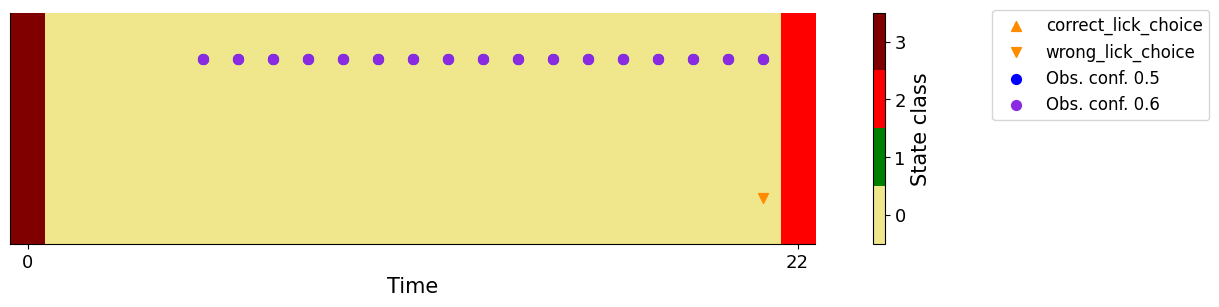

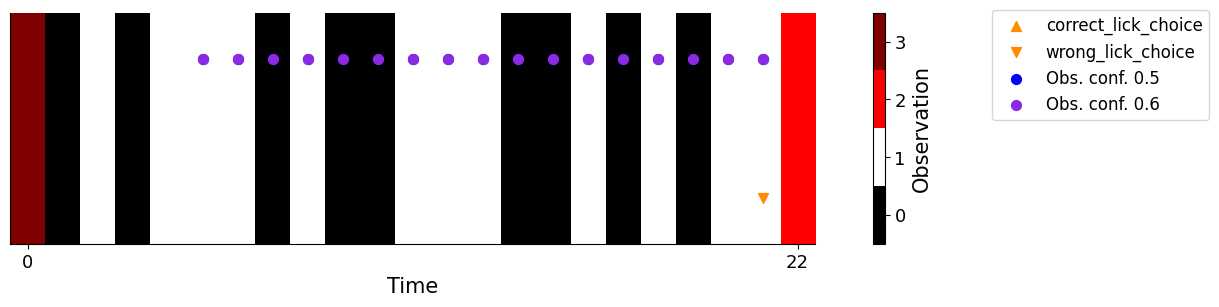

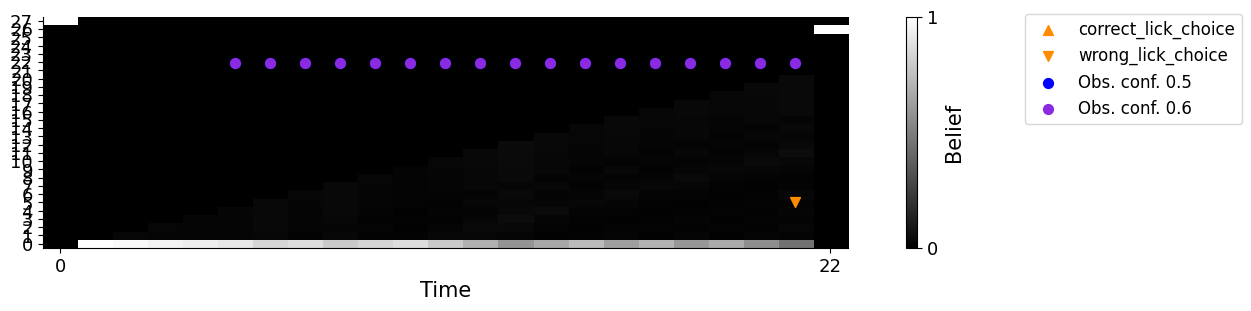

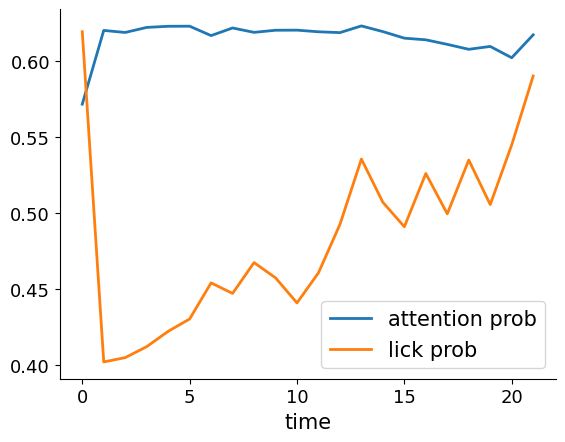

In [6]:
episode = run_one_episode(task, taskbelief, agent,
                          num_steps=1000)
print('reward: ',food_reward_list[episode['trial_food_reward_idx']])
fig = plot_AF_episode(episode, task, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())


lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.xlabel('time')
plt.legend()
plt.show()

## Analysis over trials

### Time analysis - plots

In [77]:
# run mp job

def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                              num_steps=100000)
    return episode

with multiprocessing.Pool(processes=27) as pool:
    all_episode_data = pool.map(eval_wrapper, range(num_episodes))

all_reward_res={} # k: v = foodreward: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len


for episode in all_episode_data:
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    trial_len.append(len(episode['actions']))

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


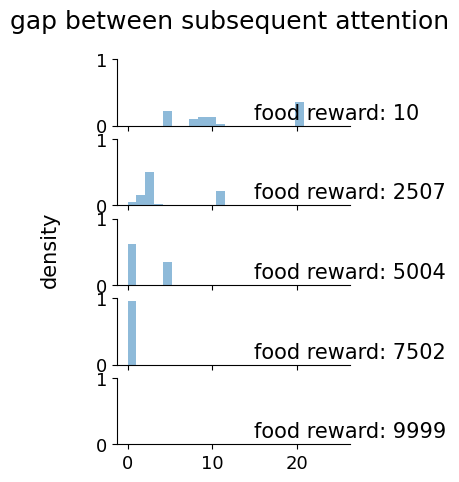

In [8]:
# plot
fig, axs=plt.subplots(len(food_reward_list),1, figsize=(3,len(food_reward_list)), sharex=True)
for food_reward_idx in all_reward_res.keys():
    try:
        attention_prob_list,lick_prob_list,lick_time_list,att_time_list=all_reward_res[food_reward_idx]
        ax=axs[food_reward_idx]
        
        data=att_time_list

        v = find_gap(pad_zero_attention(data))
        # v = (v - min(v)) / (max(v) - min(v))
        # v = 1-v
        # sns.kdeplot(v, fill=False, bw_adjust=0.99,ax=ax)
        ax.text(15,0.1,f'food reward: {food_reward_list[food_reward_idx]:.0f}')
        ax.hist(v, alpha=0.5, bins=np.linspace(0,25,25), density= True)
        ax.set_ylim(0,1)
    except Exception as e:
        print(e)
        continue
fig.text(-0.1, 0.5, 'density', va='center', ha='center', rotation='vertical')
title = 'gap between subsequent attention' 
plt.suptitle(title)
# plt.legend()
plt.show()

## new after apr 30 dicussion

In [ ]:
# added may1st, figure 6
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    plt.figure()
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
    plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
    plt.xlabel('time in trial')
    plt.ylabel('normalized count')
    plt.title(f'attention time, normlized by trial length\nfood_reward={food_reward_list[food_reward_idx]:.0f}')
    plt.show()


## done

/tmp/ipykernel_911769/2941058181.py:12: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
/tmp/ipykernel_911769/2941058181.py:12: RuntimeWarning: invalid value encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))


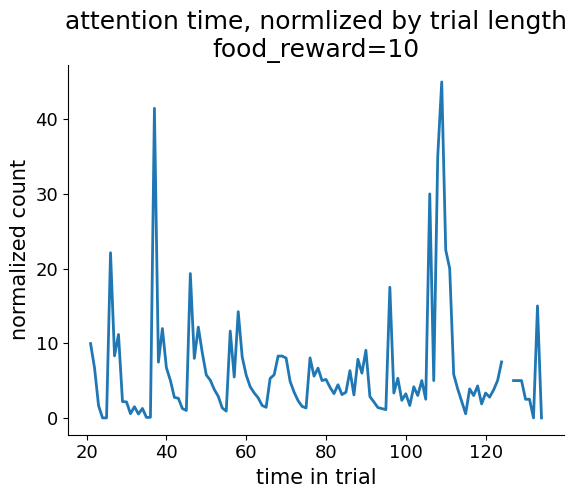

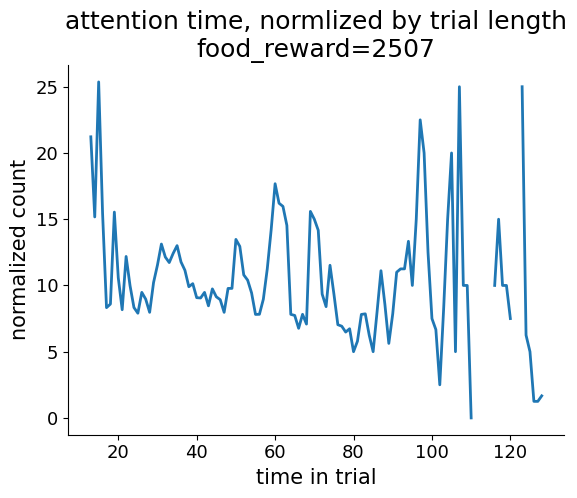

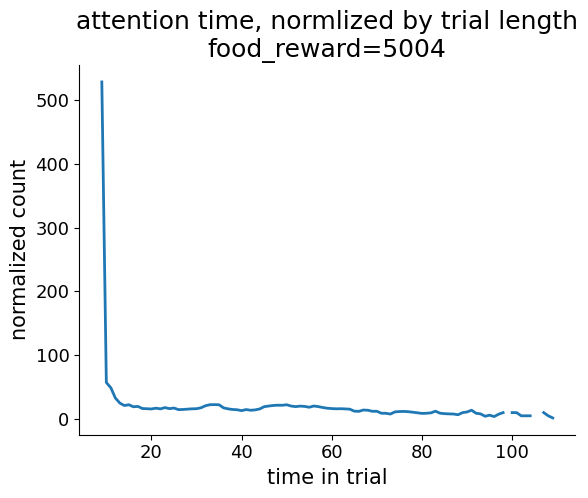

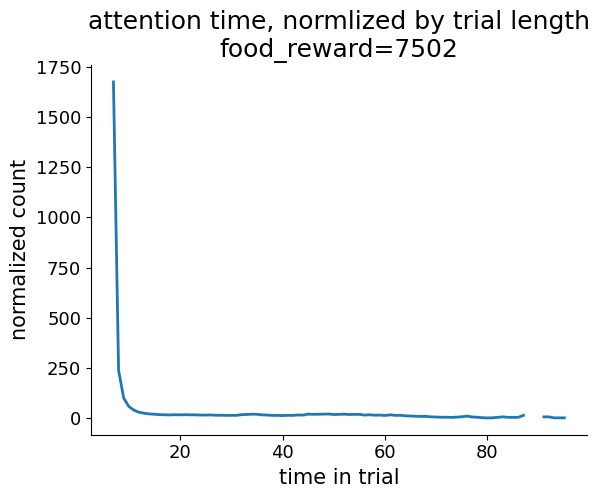

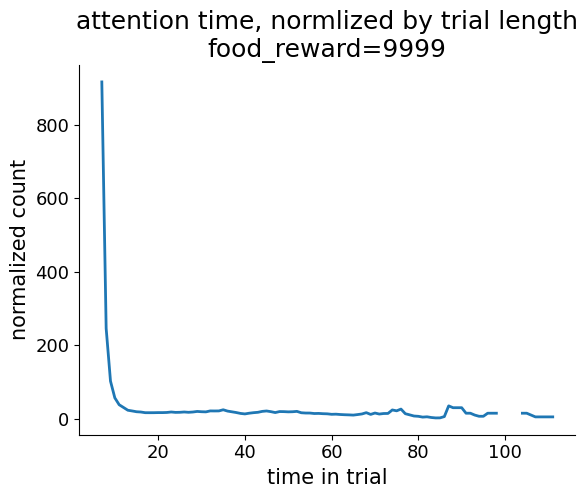

In [138]:
# added may1st, figure 6
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    plt.figure()
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
    plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
    plt.xlabel('time in trial')
    plt.ylabel('normalized count')
    plt.title(f'attention time, normlized by trial length\nfood_reward={food_reward_list[food_reward_idx]:.0f}')
    plt.show()


## orginal plots

food reward: 10.0


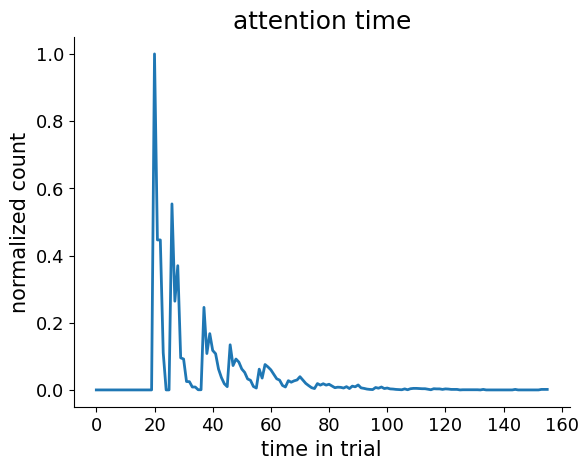

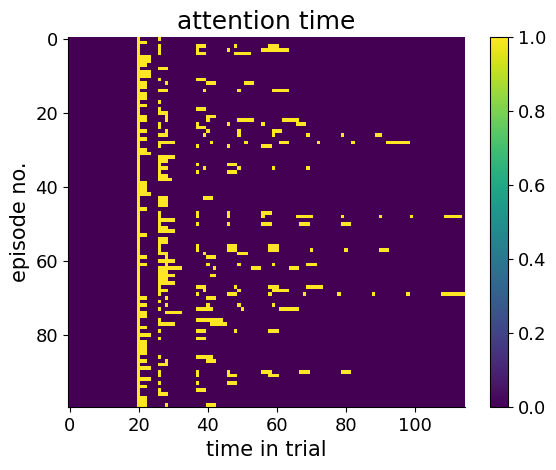

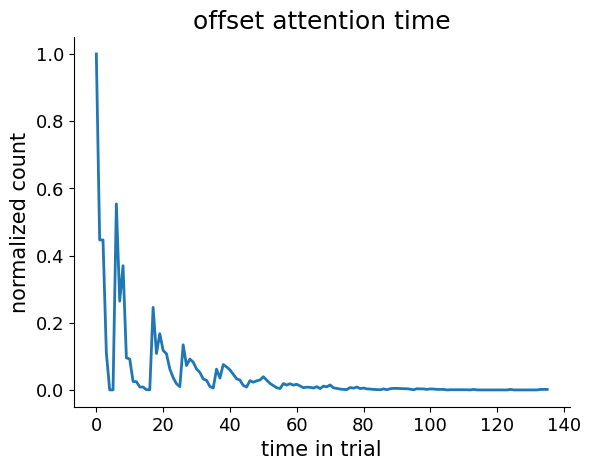

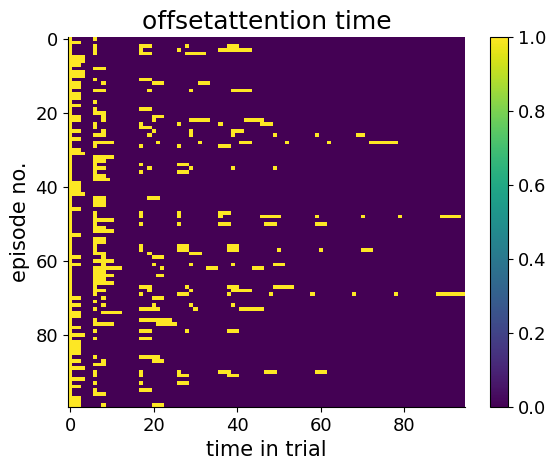

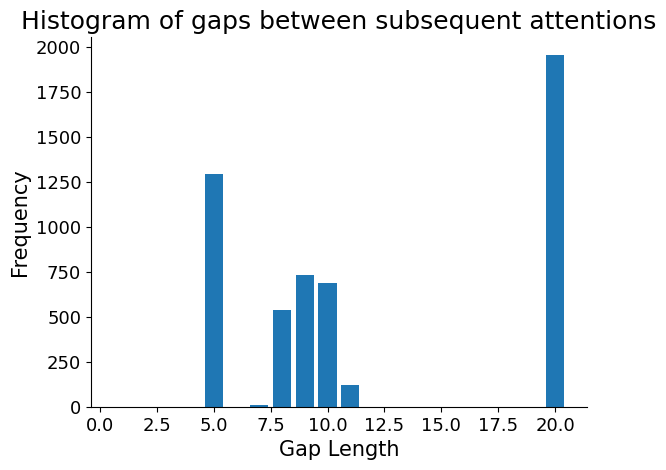

food reward: 2507.25


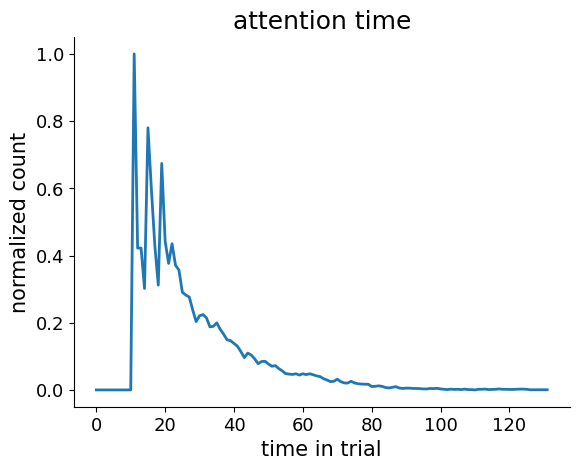

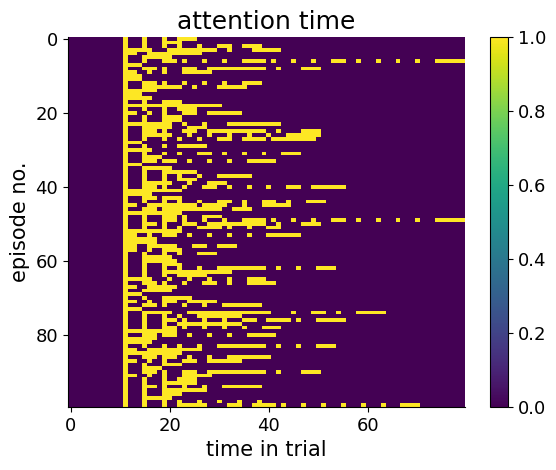

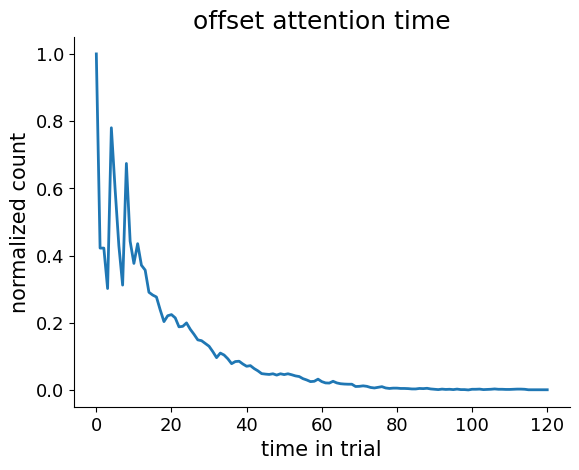

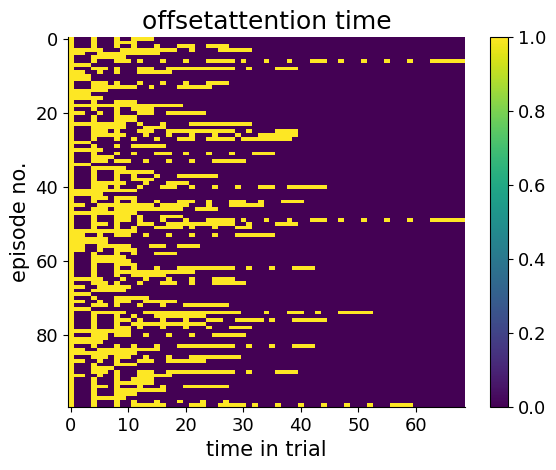

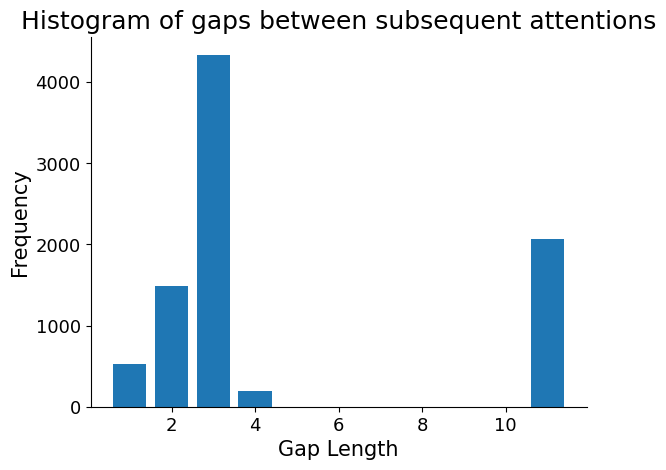

food reward: 5004.5


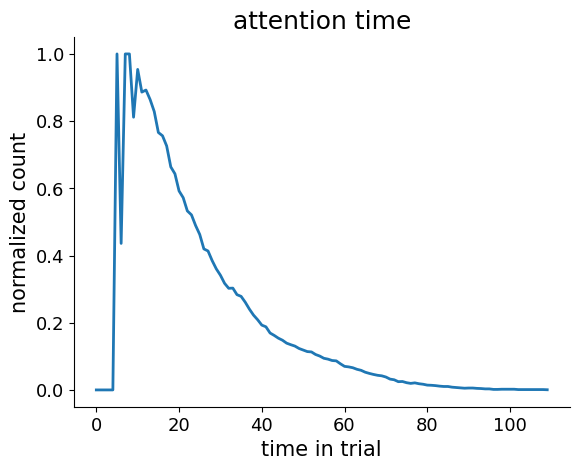

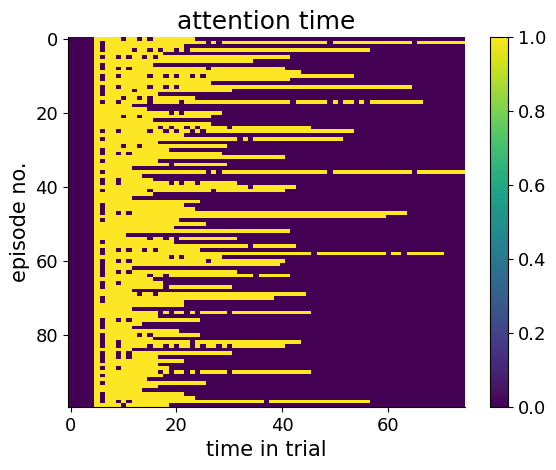

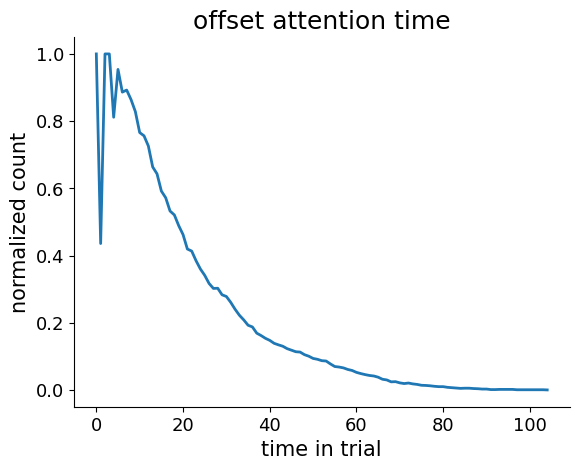

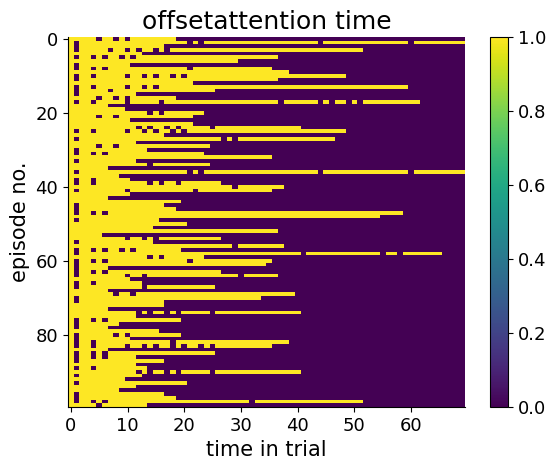

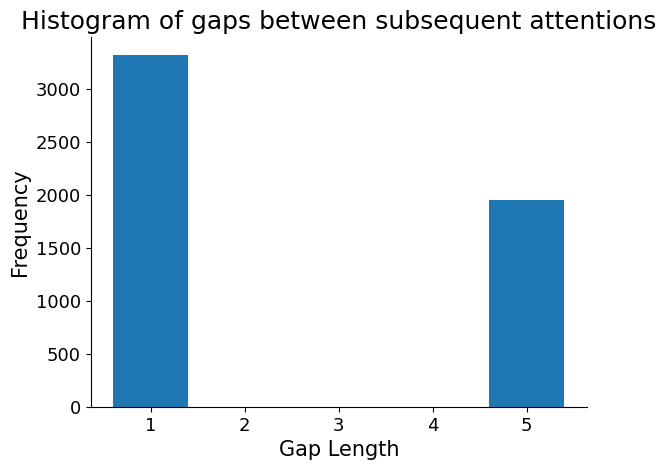

food reward: 7501.75


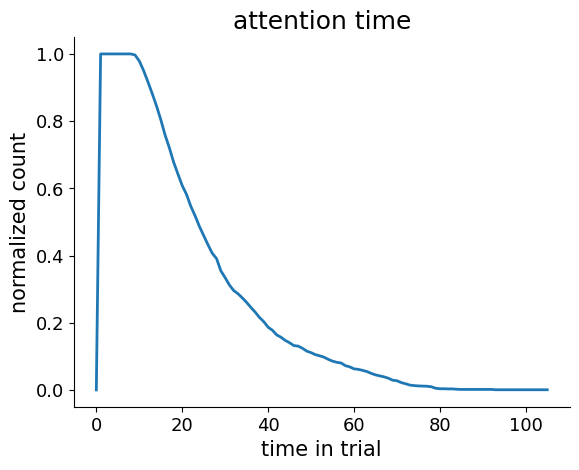

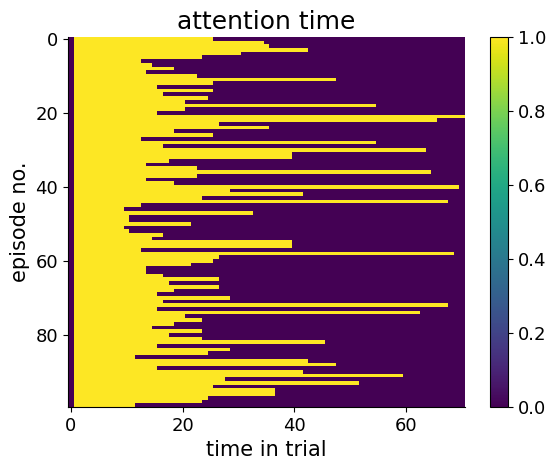

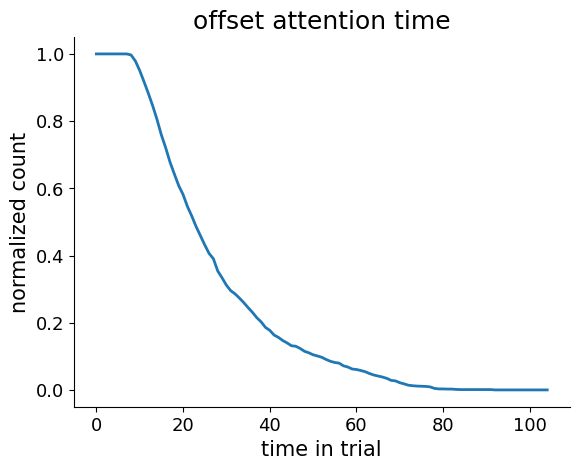

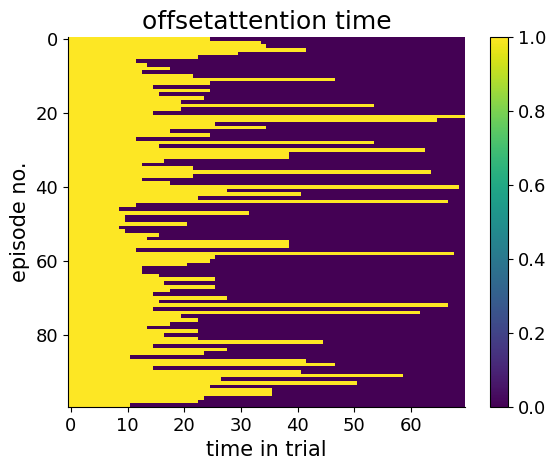

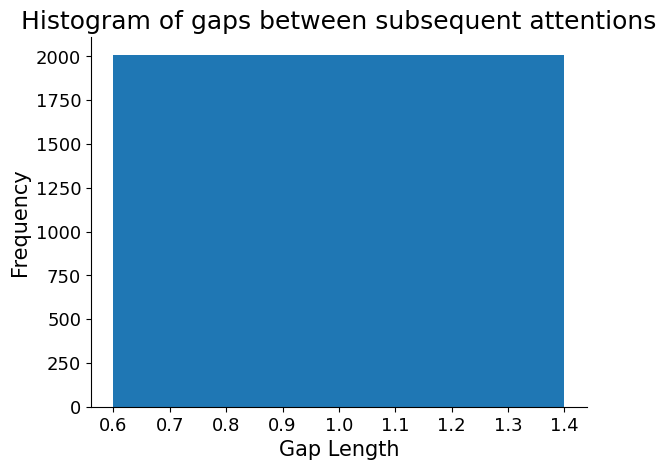

food reward: 9999.0


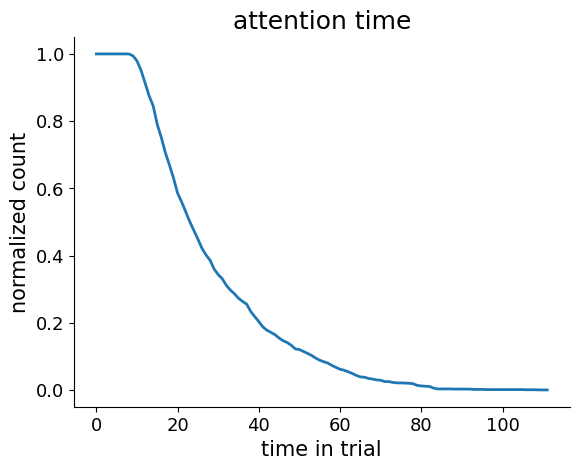

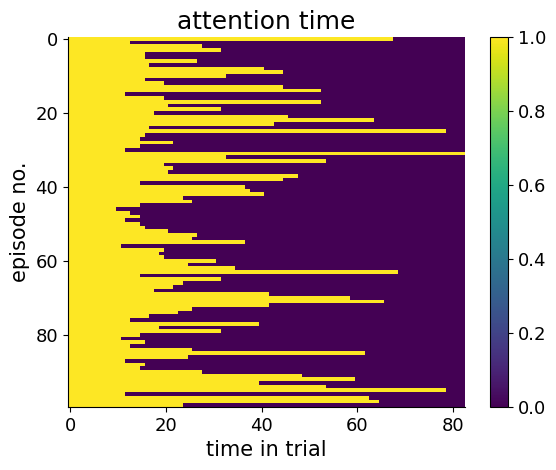

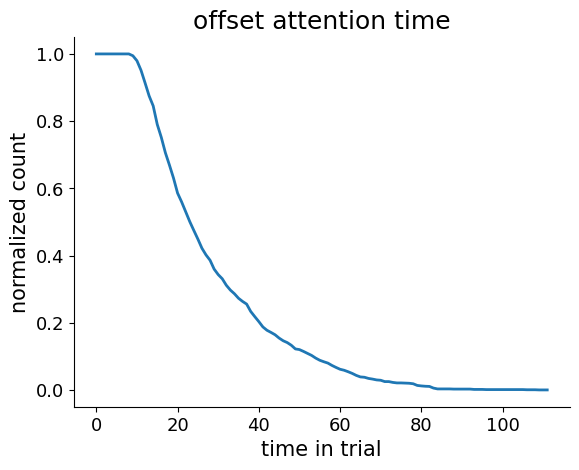

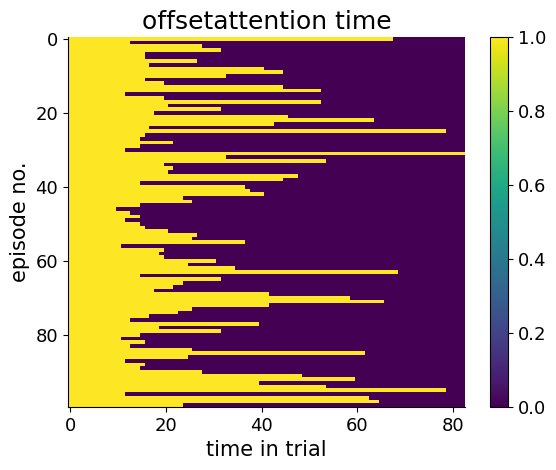

max() iterable argument is empty
bad food reward: 9999.0


<Figure size 640x480 with 0 Axes>

In [145]:
for food_reward_idx in all_reward_res.keys():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]
    print(f'food reward: {food_reward_list[food_reward_idx]}')
    try:
        # plot_over_episodes(attention_prob_list, title = 'attention prob.', plot_no_episodes = 100)
        # plot_over_episodes(lick_prob_list, title = 'lick prob.', plot_no_episodes = 100)
        # plot_over_episodes(lick_time_list, title = 'lick time', plot_no_episodes = 100)
        plot_over_episodes(att_time_list, title = 'attention time', plot_no_episodes = 100)
    except Exception as e:
        print(e)
        print(f'bad food reward: {food_reward_list[food_reward_idx]}')
        continue